# Demonotebook für ipycytoscape

In [1]:
%pip install -q ipycytoscape networkx
import ipycytoscape as cy
import networkx as nx
import pandas as pd
from ext.sparql import query, display_result

In [2]:
cyg = cy.CytoscapeWidget()
G = nx.complete_graph(5)

In [3]:
cyg.graph.add_graph_from_networkx(G)

In [4]:
cyg

CytoscapeWidget(cytoscape_layout={'name': 'cola'}, cytoscape_style=[{'selector': 'node', 'css': {'background-c…

## nx from pd

In [5]:
edges = pd.DataFrame(
    {
        "source": ["A", "A", "B", "C", "D"],
        "target": ["B", "C", "C", "D", "A"],
        "weight": [10, 8, 6, 2, 1],
        "color": ["red", "blue", "green", "yellow", "cyan"]
    }
)

In [6]:
edges

,source,target,weight,color
0,A,B,10,red
1,A,C,8,blue
2,B,C,6,green
3,C,D,2,yellow
4,D,A,1,cyan


In [7]:
G = nx.from_pandas_edgelist(edges, edge_attr=True)
cyg = cy.CytoscapeWidget()
cyg.graph.add_graph_from_networkx(G, directed=True)

In [8]:
my_style = [
    {
        'selector': 'node',
         'style': {
            'font-family': 'helvetica',
            'font-size': '20px',
            'label': 'data(id)'
         }
    },
    {
        'selector': 'edge',
        'style': {
            'font-family': 'helvetica',
            'font-size': '10px',
            'label': 'data(color)'
         }
    
    }
]

In [9]:
cyg.set_tooltip_source('source')
cyg.set_style(my_style)
cyg.set_layout(name = "dagre", nodeSpacing=10, edgeLengthVal=10)
#cyg.set_layout(name = "circle")
cyg

CytoscapeWidget(cytoscape_layout={'name': 'dagre', 'nodeSpacing': 10, 'edgeLengthVal': 10}, cytoscape_style=[{…

In [10]:
print(nx.get_edge_attributes(G, "weight"))

{('A', 'B'): 10, ('A', 'C'): 8, ('A', 'D'): 1, ('B', 'C'): 6, ('C', 'D'): 2}


In [11]:
display(G.nodes)

NodeView(('A', 'B', 'C', 'D'))

In [12]:
pd.DataFrame(G.degree(), columns = ['id', 'degree'])

,id,degree
0,A,3
1,B,2
2,C,3
3,D,2


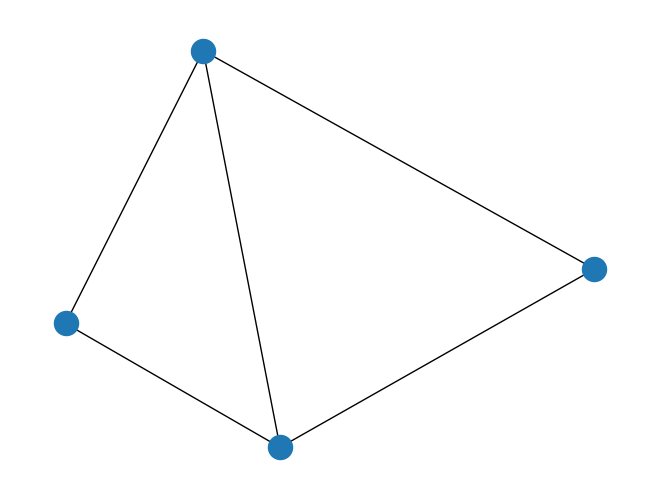

In [13]:
nx.draw(G)

In [14]:
edge_data = {
    'source': ['A', 'B', 'B', 'C'],
    'target': ['B', 'C', 'D', 'B'],
}
link_df = pd.DataFrame.from_dict(edge_data)
node_data = {
    'id': ['A', 'B', 'C', 'D', 'E']
}
node_df = pd.DataFrame.from_dict(node_data)

G = nx.from_pandas_edgelist(link_df)
node_df = pd.DataFrame(G.degree(), columns=['id', 'degree'])
print(node_df.set_index('id').to_dict('index'))
nx.set_node_attributes(G, node_df.set_index('id').to_dict('index'))
cytoscapeobj = cy.CytoscapeWidget()
cytoscapeobj.graph.add_graph_from_networkx(G)

cytoscapeobj.set_style(
    [
        {
             'selector': 'node',
             'style': {
                 'font-family': 'helvetica',
                 'font-size': '20px',
                 'label': 'data(id)'
             }
        },
        {
             'selector': 'edge',
             'style': {
                 'font-family': 'helvetica',
                 'font-size': '20px'
             }
        },
        {
             'selector': 'node[degree>0]',
             'style': {
                 'width': '100px',
                 'height': '100px'
             }
        },
        {
             'selector': 'node[degree>1]',
             'style': {
                 'width': '150px',
                 'height': '150px'
             }
        },
        {
             'selector': 'node[degree>2]',
             'style': {
                 'width': '200px',
                 'height': '200px'
             }
        }
    ]
)
cytoscapeobj

{'A': {'degree': 1}, 'B': {'degree': 3}, 'C': {'degree': 1}, 'D': {'degree': 1}}


CytoscapeWidget(cytoscape_layout={'name': 'cola'}, cytoscape_style=[{'selector': 'node', 'style': {'font-famil…

In [15]:
print(nx.get_node_attributes(G, "degree"))

{'A': 1, 'B': 3, 'C': 1, 'D': 1}


# Versuche mit dem Staatskalender

Suche die Org "Bereich DTI und IKT-Lenkung"

In [16]:
df = await query("""

PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>

SELECT * WHERE {

    ?org a vl:Identity;
        vl:inVersionedIdentitySet <https://ld.admin.ch/ou>;
        schema:name "Bereich DTI und IKT-Lenkung"@de.

} LIMIT 10
""")

display_result(df)

,org
0,https://ld.admin.ch/ou/20048177


In [17]:
df = await query("""

PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>

SELECT * WHERE {

    ?child schema:parentOrganization* <https://ld.admin.ch/ou/20048177>;
        a vl:Identity;
        vl:inVersionedIdentitySet <https://ld.admin.ch/ou>;
        schema:name ?name.
        
    FILTER(lang(?name) = "de")
}
""")

display_result(df)

,child,name
0,https://ld.admin.ch/ou/20048177,Bereich DTI und IKT-Lenkung
1,https://ld.admin.ch/ou/20048178,Transformation und Interoperabilität
2,https://ld.admin.ch/ou/20048179,Strategie und Innovation
3,https://ld.admin.ch/ou/20048180,Architektur und Interoperabilität
4,https://ld.admin.ch/ou/20048181,Pool Schlüsselprojektleiter
5,https://ld.admin.ch/ou/20048182,Digitale Standardleistungen
6,https://ld.admin.ch/ou/20048184,Digitaler Arbeitsplatz
7,https://ld.admin.ch/ou/20048185,Digitale Basis- und Sicherheitsleistunge
8,https://ld.admin.ch/ou/20048187,Dienstleistungen Digitalisierung
9,https://ld.admin.ch/ou/20048188,Digitale Schweiz


In [18]:
df = await query("""

PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>

SELECT ?source ?target WHERE {

    #?child schema:parentOrganization* <https://ld.admin.ch/ou/10000025>;
    ?child schema:parentOrganization* <https://ld.admin.ch/ou/20048177>;
        a vl:Identity;
        vl:inVersionedIdentitySet <https://ld.admin.ch/ou>;
        schema:parentOrganization ?parent;
        schema:name ?source.
    ?parent schema:name ?target.
    
    FILTER(lang(?source) = "de")
    FILTER(lang(?target) = "de")

}
""")

display_result(df)

,source,target
0,Bereich DTI und IKT-Lenkung,Bundeskanzlei
1,Dienstleistungen Digitalisierung,Bereich DTI und IKT-Lenkung
2,Digitale Standardleistungen,Bereich DTI und IKT-Lenkung
3,Digitale Schweiz,Bereich DTI und IKT-Lenkung
4,Transformation und Interoperabilität,Bereich DTI und IKT-Lenkung
5,Strategie und Innovation,Transformation und Interoperabilität
6,Pool Schlüsselprojektleiter,Transformation und Interoperabilität
7,Architektur und Interoperabilität,Transformation und Interoperabilität
8,Digitale geschäftsunterstützende Dienste,Digitale Standardleistungen
9,Digitaler Arbeitsplatz,Digitale Standardleistungen


In [19]:
G = nx.from_pandas_edgelist(df, create_using=nx.DiGraph())

my_style = [
    {
        'selector': 'node',
         'style': {
            'font-family': 'helvetica',
            'font-size': '8px',
            'label': 'data(id)'
         }
    },
    {
        "selector": "edge.directed",
        "style": {
            "curve-style": "bezier",
            "target-arrow-shape": "triangle",
            "target-arrow-color": "#9dbaea",
        }
    }
]

dti = cy.CytoscapeWidget()
dti.graph.add_graph_from_networkx(G, directed=True)
dti.set_style(my_style)
#dti.set_layout(name = "dagre", rankDir = "BT")
dti

CytoscapeWidget(cytoscape_layout={'name': 'cola'}, cytoscape_style=[{'selector': 'node', 'style': {'font-famil…